CSV used: RE_Essays_Dataset_2026 - classexampleOpenAI.csv
Number of essays: 100

Columns: ['Name', 'Grade', 'Course', 'Date', 'Teacher', 'Text', 'results', 'grade', 'summary', 'char_length', 'word_count']

Missing values:
 Name            0
Grade           0
Course         11
Date           25
Teacher        16
Text            0
results        12
grade          11
summary        13
char_length     0
word_count      0
dtype: int64

Essay length (characters):
 count      100.000000
mean      6763.360000
std       4461.102522
min          4.000000
25%       3756.000000
50%       5517.000000
75%       8318.500000
max      27452.000000
Name: char_length, dtype: float64

Essay length (words):
 count     100.000000
mean     1110.350000
std       675.662838
min         1.000000
25%       641.000000
50%       939.000000
75%      1443.000000
max      3991.000000
Name: word_count, dtype: float64

Teacher distribution:
 Teacher
Missing                      16
Dr. Margini                  14
Dr. Ch

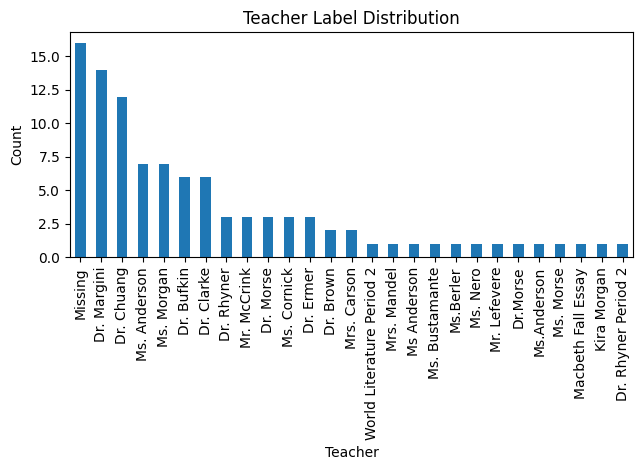

/tmp/ipython-input-917672100.py:57: UserWarning: Glyph 128 (\x80) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-917672100.py:57: UserWarning: Glyph 147 (\x93) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128 (\x80) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 147 (\x93) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


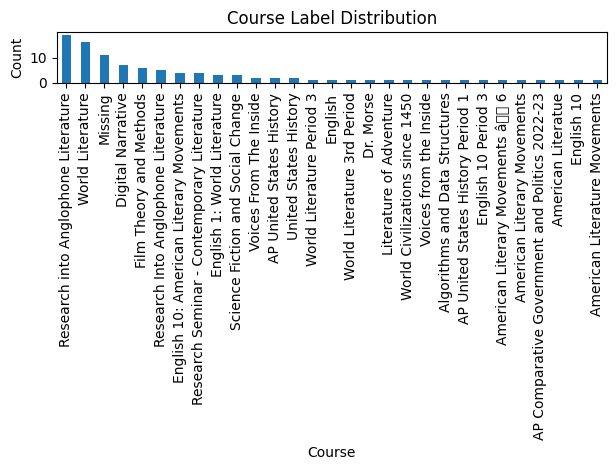

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

path_candidates = [
    "/mnt/data/RE_Essays_Dataset_2026 - classexampleOpenAI.csv",
    "RE_Essays_Dataset_2026 - classexampleOpenAI.csv",
    "RE_Essay_Dataset_2026 - classexampleOpenAI.csv",
    "classexampleOpenAI.csv"
]
csv_path = next((p for p in path_candidates if os.path.exists(p)), None)

df = pd.read_csv(csv_path)

#removes the known bad row where the Course field is not a real course.
bad_mask = df["Course"].astype(str).str.startswith("Most of the things", na=False)
df = df.loc[~bad_mask].reset_index(drop=True)

df["Teacher"] = df["Teacher"].astype("string").str.strip()
df["Course"] = df["Course"].astype("string").str.strip()
df["Text"] = df["Text"].astype("string")

#creates basic length features to understand essay size variability
df["char_length"] = df["Text"].fillna("").astype(str).apply(len)
df["word_count"] = df["Text"].fillna("").astype(str).apply(lambda x: len(x.split()))

print("CSV used:", csv_path)
print("Number of essays:", len(df))
print("\nColumns:", df.columns.tolist())
print("\nMissing values:\n", df.isnull().sum())

print("\nEssay length (characters):\n", df["char_length"].describe())
print("\nEssay length (words):\n", df["word_count"].describe())

teacher_counts = df["Teacher"].fillna("Missing").value_counts()
course_counts = df["Course"].fillna("Missing").value_counts()

print("\nTeacher distribution:\n", teacher_counts)
print("\nCourse distribution:\n", course_counts)

#plots teacher label frequencies to check class imbalance.
plt.figure()
teacher_counts.plot(kind="bar")
plt.title("Teacher Label Distribution")
plt.xlabel("Teacher")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

#plots course label frequencies to check class imbalance.
plt.figure()
course_counts.plot(kind="bar")
plt.title("Course Label Distribution")
plt.xlabel("Course")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


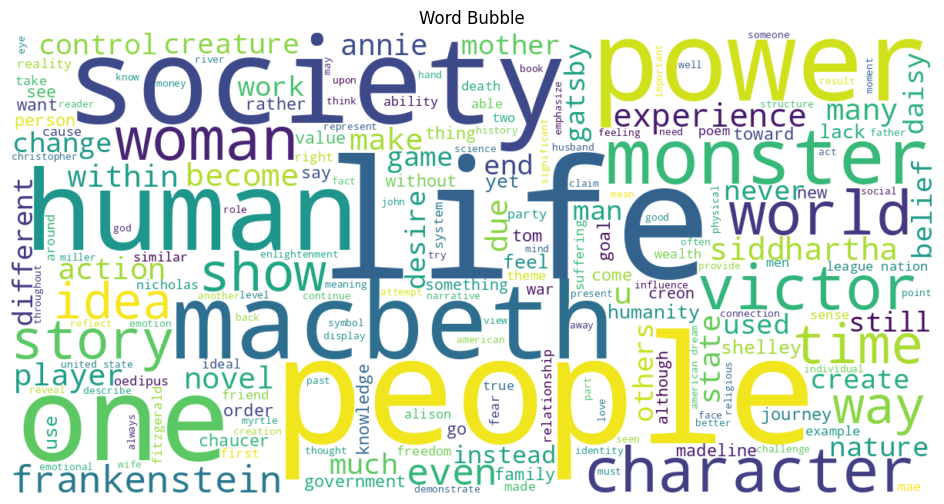

In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

#downloads the NLTK resources
nltk.download("stopwords")
nltk.download("wordnet")

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    # lowercases text so the same word is treated consistently.
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)

# applies preprocessing to create the cleaned modeling text column.
df["clean_text"] = df["Text"].fillna("").apply(preprocess_text)

try:
    from wordcloud import WordCloud
except Exception:
    import sys
    !{sys.executable} -m pip -q install wordcloud
    from wordcloud import WordCloud

# generates a word bubble
wc_text = " ".join(df["clean_text"].astype(str).tolist())
wc = WordCloud(width=1200, height=600, background_color="white").generate(wc_text)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Word Bubble")
plt.show()


In [ ]:
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score

def vectorizer_leaderboard(X_train, y_train, X_val, y_val):
    # sets up multiple vectorizers so you can compare feature choices
    configs = [
        ("Count (1,1)", CountVectorizer(ngram_range=(1, 1))),
        ("Count (1,2)", CountVectorizer(ngram_range=(1, 2))),
        ("Count (1,3)", CountVectorizer(ngram_range=(1, 3))),
        ("TFIDF (1,1)", TfidfVectorizer(ngram_range=(1, 1))),
        ("TFIDF (1,2)", TfidfVectorizer(ngram_range=(1, 2))),
        ("TFIDF (1,3)", TfidfVectorizer(ngram_range=(1, 3))),
    ]
    rows = []
    for name, vec in configs:
        # lones the vectorizer to prevent shared vocabulary bugs across runs
        pipe = Pipeline([("vec", clone(vec)), ("clf", LinearSVC())])
        pipe.fit(X_train, y_train)
        pred = pipe.predict(X_val)
        rows.append({
            "vectorizer": name,
            "val_accuracy": accuracy_score(y_val, pred),
            "val_macro_f1": f1_score(y_val, pred, average="macro")
        })
    # sorts results so you can pick the best vectorizer by macro F1
    return pd.DataFrame(rows).sort_values(["val_macro_f1", "val_accuracy"], ascending=False).reset_index(drop=True)

In [ ]:
from sklearn.model_selection import train_test_split

def collapse_rare_labels(y, min_count=3, other_label="Other"):
    y = y.astype(str)
    counts = y.value_counts()
    rare = counts[counts < min_count].index
    return y.where(~y.isin(rare), other_label)

def make_splits(X, y, test_size=0.20, val_size=0.15, random_state=42):
    X_trainval, X_test, y_trainval, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=random_state
    )
    val_frac = val_size / (1 - test_size)
    X_train, X_val, y_train, y_val = train_test_split(
        X_trainval, y_trainval, test_size=val_frac, stratify=y_trainval, random_state=random_state
    )
    return X_train, X_val, X_test, y_train, y_val, y_test

df_teacher = df.dropna(subset=["Teacher"]).copy()
df_course = df.dropna(subset=["Course"]).copy()

X_t = df_teacher["clean_text"].astype(str)
y_t = collapse_rare_labels(df_teacher["Teacher"].astype(str), min_count=3)

X_c = df_course["clean_text"].astype(str)
y_c = collapse_rare_labels(df_course["Course"].astype(str), min_count=3)

X_train_t, X_val_t, X_test_t, y_train_t, y_val_t, y_test_t = make_splits(X_t, y_t)
X_train_c, X_val_c, X_test_c, y_train_c, y_val_c, y_test_c = make_splits(X_c, y_c)

print("Teacher split sizes:", len(X_train_t), len(X_val_t), len(X_test_t))
print("Course split sizes:", len(X_train_c), len(X_val_c), len(X_test_c))
print("Teacher classes:", y_t.nunique())
print("Course classes:", y_c.nunique())


Teacher split sizes: 54 13 17
Course split sizes: 57 14 18
Teacher classes: 12
Course classes: 10


In [ ]:
import itertools
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

def tune_models(X_train, y_train, X_val, y_val):
    vec_space = [
        ("TFIDF (1,2)", TfidfVectorizer(ngram_range=(1, 2))),
        ("TFIDF (1,1)", TfidfVectorizer(ngram_range=(1, 1))),
        ("Count (1,2)", CountVectorizer(ngram_range=(1, 2))),
    ]
    model_space = [
        ("LogReg", LogisticRegression(max_iter=4000, solver="liblinear")),
        ("RF", RandomForestClassifier(random_state=42)),
    ]
    grids = {
        "LogReg": {"clf__C": [0.1, 1, 3, 10]},
        "RF": {"clf__n_estimators": [200, 500], "clf__max_depth": [None, 30, 60], "clf__min_samples_split": [2, 5]},
    }
    rows = []
    best_pipe = None
    best_score = -1
    for vec_name, vec in vec_space:
        for model_name, model in model_space:
            keys = list(grids[model_name].keys())
            for vals in itertools.product(*[grids[model_name][k] for k in keys]):
                params = dict(zip(keys, vals))
                # trains a candidate pipeline and scores it on the validation set
                pipe = Pipeline([("vec", clone(vec)), ("clf", clone(model))]).set_params(**params)
                pipe.fit(X_train, y_train)
                pred = pipe.predict(X_val)
                acc = accuracy_score(y_val, pred)
                macro = f1_score(y_val, pred, average="macro")
                rows.append({"vectorizer": vec_name, "model": model_name, "params": params, "val_accuracy": acc, "val_macro_f1": macro})
                # selects the best model using macro F1 to handle imbalance.
                if macro > best_score:
                    best_score = macro
                    best_pipe = pipe
    results = pd.DataFrame(rows).sort_values(["val_macro_f1", "val_accuracy"], ascending=False).reset_index(drop=True)
    return best_pipe, results

best_teacher_pipe, teacher_tuning = tune_models(X_train_t, y_train_t, X_val_t, y_val_t)
best_course_pipe, course_tuning = tune_models(X_train_c, y_train_c, X_val_c, y_val_c)

print("Teacher tuning top 10:\n", teacher_tuning.head(10))
print("\nCourse tuning top 10:\n", course_tuning.head(10))


Teacher tuning top 10:
     vectorizer   model                                             params  \
0  TFIDF (1,1)  LogReg                                     {'clf__C': 10}   
1  Count (1,2)  LogReg                                    {'clf__C': 0.1}   
2  Count (1,2)  LogReg                                      {'clf__C': 1}   
3  Count (1,2)  LogReg                                      {'clf__C': 3}   
4  Count (1,2)  LogReg                                     {'clf__C': 10}   
5  TFIDF (1,2)  LogReg                                     {'clf__C': 10}   
6  TFIDF (1,1)  LogReg                                      {'clf__C': 3}   
7  TFIDF (1,1)      RF  {'clf__n_estimators': 200, 'clf__max_depth': N...   
8  TFIDF (1,1)      RF  {'clf__n_estimators': 200, 'clf__max_depth': 3...   
9  TFIDF (1,1)      RF  {'clf__n_estimators': 200, 'clf__max_depth': 6...   

   val_accuracy  val_macro_f1  
0      0.615385      0.422222  
1      0.615385      0.412963  
2      0.615385      0.412963  



Teacher Prediction
Accuracy: 0.5294117647058824
Macro F1: 0.35912698412698413
Weighted F1: 0.4467787114845938
Majority baseline accuracy: 0.17647058823529413
Random guessing (1/K): 0.08333333333333333

Classification report:
               precision    recall  f1-score   support

  Dr. Bufkin     0.3333    1.0000    0.5000         1
  Dr. Chuang     1.0000    1.0000    1.0000         2
  Dr. Clarke     0.0000    0.0000    0.0000         1
   Dr. Ermer     1.0000    1.0000    1.0000         1
 Dr. Margini     0.7500    1.0000    0.8571         3
   Dr. Morse     0.0000    0.0000    0.0000         1
  Dr. Rhyner     0.0000    0.0000    0.0000         1
 Mr. McCrink     0.0000    0.0000    0.0000         1
Ms. Anderson     0.0000    0.0000    0.0000         1
 Ms. Cornick     0.0000    0.0000    0.0000         1
  Ms. Morgan     0.5000    1.0000    0.6667         1
       Other     0.2500    0.3333    0.2857         3

    accuracy                         0.5294        17
   macro avg   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


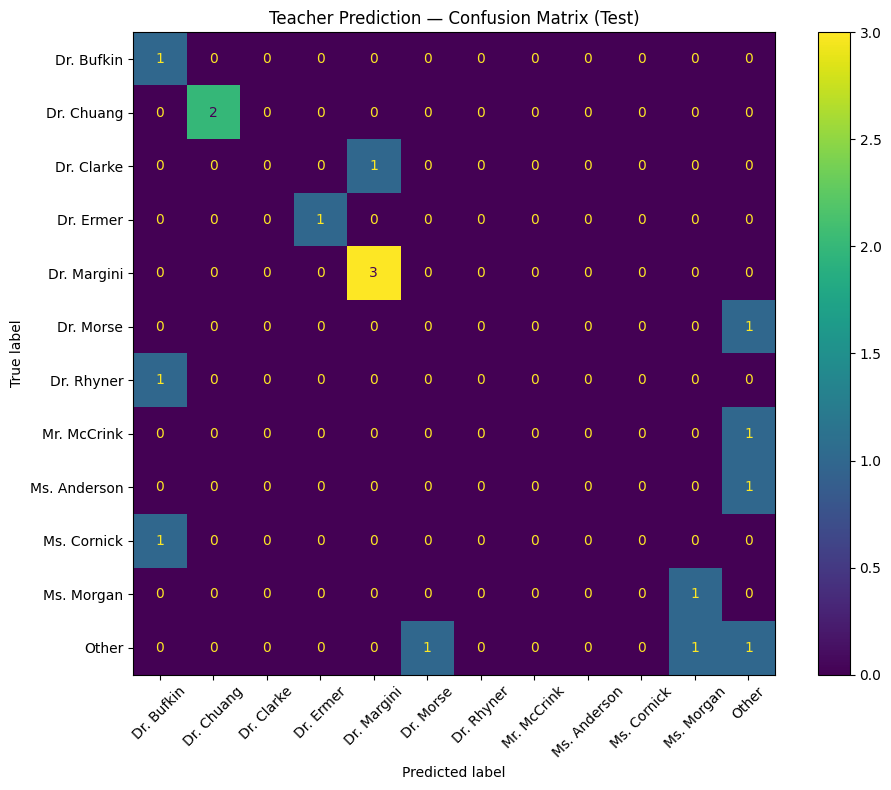

ROC-AUC (macro OvR): 0.8353174603174603

Course Prediction
Accuracy: 0.4444444444444444
Macro F1: 0.21666666666666665
Weighted F1: 0.31481481481481477
Majority baseline accuracy: 0.2222222222222222
Random guessing (1/K): 0.1

Classification report:
                                             precision    recall  f1-score   support

                         Digital Narrative     1.0000    1.0000    1.0000         1
   English 10: American Literary Movements     0.0000    0.0000    0.0000         1
               English 1: World Literature     0.0000    0.0000    0.0000         1
                   Film Theory and Methods     0.0000    0.0000    0.0000         1
                                     Other     0.3333    1.0000    0.5000         4
       Research Into Anglophone Literature     0.0000    0.0000    0.0000         1
Research Seminar - Contemporary Literature     0.0000    0.0000    0.0000         1
       Research into Anglophone Literature     0.6000    0.7500    0.6667    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


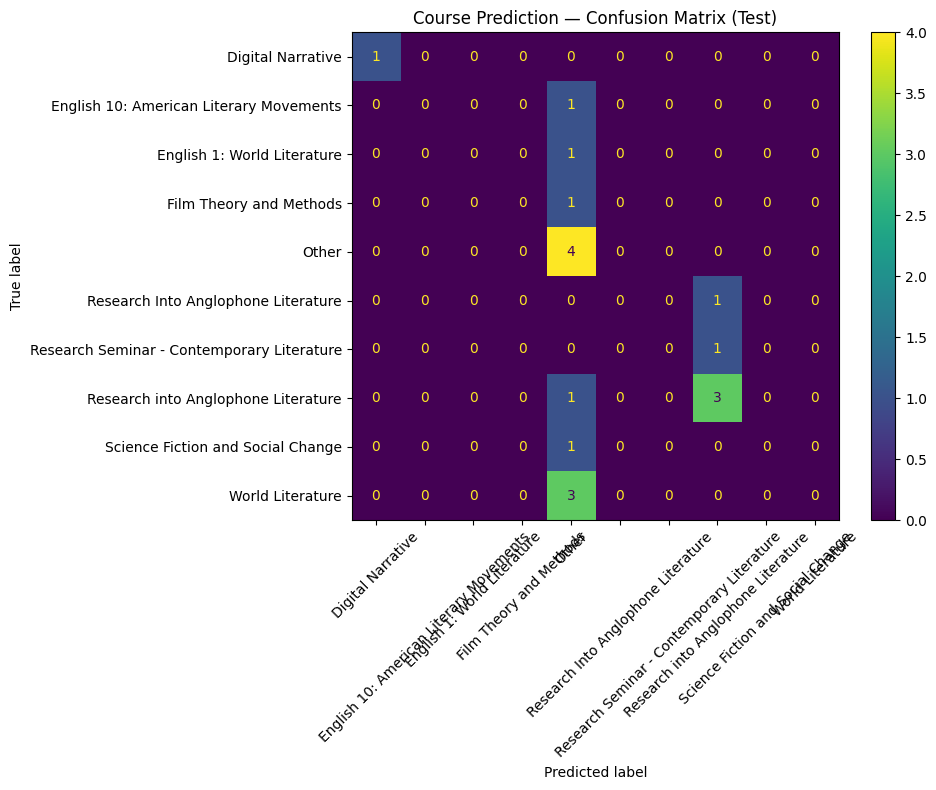

ROC-AUC (macro OvR): 0.7942623716153128


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_auc_score
from sklearn.preprocessing import label_binarize

def refit_train_val(pipe, X_train, y_train, X_val, y_val):
    # refits on train plus validation so the final model uses more data
    X_tv = pd.concat([X_train, X_val])
    y_tv = pd.concat([y_train, y_val])
    pipe.fit(X_tv, y_tv)
    return pipe

def evaluate(pipe, X_train, y_train, X_val, y_val, X_test, y_test, title):
    pipe = refit_train_val(pipe, X_train, y_train, X_val, y_val)
    pred = pipe.predict(X_test)
    acc = accuracy_score(y_test, pred)
    macro = f1_score(y_test, pred, average="macro")
    weighted = f1_score(y_test, pred, average="weighted")
    # computes a majority baseline so accuracy has a meaningful reference point
    maj = y_train.value_counts().idxmax()
    maj_acc = accuracy_score(y_test, np.array([maj] * len(y_test)))
    rand_acc = 1 / len(pd.Series(y_test).unique())
    print("\n" + title)
    print("Accuracy:", acc)
    print("Macro F1:", macro)
    print("Weighted F1:", weighted)
    print("Majority baseline accuracy:", maj_acc)
    print("Random guessing (1/K):", rand_acc)
    print("\nClassification report:\n", classification_report(y_test, pred, digits=4))
    labels = sorted(pd.Series(y_test).astype(str).unique())
    cm = confusion_matrix(y_test.astype(str), pd.Series(pred).astype(str), labels=labels)
    # plots a confusion matrix so you can see systematic confusions
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    fig, ax = plt.subplots(figsize=(10, 8))
    disp.plot(ax=ax, xticks_rotation=45, values_format="d")
    ax.set_title(title + " — Confusion Matrix (Test)")
    plt.tight_layout()
    plt.show()
    roc = None
    if hasattr(pipe.named_steps["clf"], "predict_proba"):
        proba = pipe.predict_proba(X_test)
        y_bin = label_binarize(y_test.astype(str), classes=labels)
        roc = roc_auc_score(y_bin, proba, average="macro", multi_class="ovr")
        print("ROC-AUC (macro OvR):", roc)
    return pipe

teacher_final_pipe = evaluate(best_teacher_pipe, X_train_t, y_train_t, X_val_t, y_val_t, X_test_t, y_test_t, "Teacher Prediction")
course_final_pipe = evaluate(best_course_pipe, X_train_c, y_train_c, X_val_c, y_val_c, X_test_c, y_test_c, "Course Prediction")


In [ ]:
import numpy as np

def top_terms_from_linear_model(pipe, top_n=15):
    vec = pipe.named_steps["vec"]
    clf = pipe.named_steps["clf"]
    # only works for models that expose linear coefficients
    if not hasattr(clf, "coef_"):
        return None
    feature_names = vec.get_feature_names_out()
    classes = clf.classes_
    coefs = clf.coef_
    out = {}
    if len(classes) == 2 and coefs.shape[0] == 1:
        pos = np.argsort(coefs[0])[::-1][:top_n]
        neg = np.argsort(coefs[0])[:top_n]
        out[str(classes[1])] = list(zip(feature_names[pos], coefs[0][pos]))
        out[str(classes[0])] = list(zip(feature_names[neg], coefs[0][neg]))
        return out
    for i, cls in enumerate(classes):
        # prints the highest-weight terms that push toward each class.
        idx = np.argsort(coefs[i])[::-1][:top_n]
        out[str(cls)] = list(zip(feature_names[idx], coefs[i][idx]))
    return out

teacher_terms = top_terms_from_linear_model(teacher_final_pipe, top_n=15)
course_terms = top_terms_from_linear_model(course_final_pipe, top_n=15)

print("Teacher top terms available:", teacher_terms is not None)
if teacher_terms is not None:
    for cls, items in teacher_terms.items():
        print("\nTeacher class:", cls)
        for term, w in items:
            print(term, float(w))

print("\nCourse top terms available:", course_terms is not None)
if course_terms is not None:
    for cls, items in course_terms.items():
        print("\nCourse class:", cls)
        for term, w in items:
            print("\nCourse class:", cls)
            for term, w in items:
                print(term, float(w))


Teacher top terms available: True

Teacher class: Dr. Bufkin
croesus 2.2912360691666547
sublime 1.8049595384671187
myrtle 1.6638303001068853
oppenheimer 1.5500073446317306
prioress 1.461906395330707
simulation 1.4456931224181486
levy 1.3911076134226117
wealth 1.3364068114214185
tale 1.076074036732456
chaucer 1.0644336927037283
daisy 0.9953587664391583
matrix 0.972006639735976
gatsby 0.9597764759040533
party 0.9580402106671391
rich 0.9531733041235341

Teacher class: Dr. Chuang
frankenstein 2.695206220848218
monster 2.1162728851070876
disability 2.0349858734749717
chaucer 1.6518405991088694
nicholas 1.6396640058914347
arcadia 1.4587372430120724
byzantium 1.4319613147831152
yeats 1.4319613147831152
alison 1.400940818039968
boccaccio 1.3707753092703545
john 1.3265256398923786
poem 1.139832662777845
keats 1.134573411231612
smile 1.1239244566797963
mona 1.1239244566797963

Teacher class: Dr. Clarke
film 2.1735527479055334
anderson 1.6745289737751443
richie 1.5330972114244732
viewer 1.4712445

In [ ]:
import numpy as np

def top_confusions(cm, labels, k=8):
    cm2 = cm.copy()
    np.fill_diagonal(cm2, 0)
    flat = cm2.flatten()
    top_idx = np.argsort(flat)[::-1][:k]
    n = cm2.shape[0]
    out = []
    for idx in top_idx:
        i, j = divmod(idx, n)
        if cm2[i, j] > 0:
            out.append((labels[i], labels[j], int(cm2[i, j])))
    return out

def excerpt(s, n=280):
    # keeps excerpts short so you can paste them into your report
    s = str(s).replace("\n", " ").strip()
    return s[:n] + ("..." if len(s) > n else "")

def error_analysis(pipe, X_test, y_test, df_source, label_name, raw_text_col="Text", k_pairs=6, k_examples=2):
    pred = pd.Series(pipe.predict(X_test), index=X_test.index).astype(str)
    y_true = pd.Series(y_test, index=X_test.index).astype(str)
    labels = sorted(y_true.unique())
    cm = confusion_matrix(y_true, pred, labels=labels)
    pairs = top_confusions(cm, labels, k=k_pairs)
    # prints the biggest confusions so you can explain them clearly
    print("\nTop confusions for", label_name)
    for a, b, c in pairs:
        print(a, "->", b, ":", c)
    print("\nMisclassified excerpts for", label_name)
    for a, b, _ in pairs:
        idxs = y_true[(y_true == a) & (pred == b)].index[:k_examples]
        if len(idxs) == 0:
            continue
        print("\nTrue =", a, "| Pred =", b)
        for idx in idxs:
            print("-", excerpt(df_source.loc[idx, raw_text_col] if idx in df_source.index else ""))
    return cm, labels

teacher_cm, teacher_labels = error_analysis(teacher_final_pipe, X_test_t, y_test_t, df_teacher, "Teacher")
course_cm, course_labels = error_analysis(course_final_pipe, X_test_c, y_test_c, df_course, "Course")



Top confusions for Teacher
Other -> Ms. Morgan : 1
Other -> Dr. Morse : 1
Dr. Clarke -> Dr. Margini : 1
Dr. Morse -> Other : 1
Mr. McCrink -> Other : 1
Dr. Rhyner -> Dr. Bufkin : 1

Misclassified excerpts for Teacher

True = Other | Pred = Ms. Morgan
- in recent years the world has witnessed remarkable advancements in artificial intelligence revolutionizing various sectors and opening up new possibilities for innovation and scientific discovery with its capacity to analyze vast amounts of data and make informed decisions ai has...

True = Other | Pred = Dr. Morse
- nolan wu  world literature period  dr morse february   symbols of the river  the novel siddhartha by hermann hesse is a book that follows the perspective of siddhartha a young indian brahmin who goes on a quest to find enlightenment siddhartha goes on a path of asceticism then to...

True = Dr. Clarke | Pred = Dr. Margini
- Near the climax of Arrival, Louis re-enters the Heptapod ship completely alone. After learning that t

In [ ]:
improvements = [
    # This addresses missing labels so the model does not learn a fake class.
    "Clean labels before training by removing missing Teacher or Course rows so the model does not learn a fake nan class.",
    # This prevents duplicate course labels caused by inconsistent capitalization.
    "Normalize Course names by stripping whitespace and standardizing capitalization to avoid duplicate classes.",
    # This improves generalization by giving each class enough examples.
    "Collect more essays per teacher and per course so the model has enough examples to learn stable patterns.",
    "Use tuned n-grams with min_df and max_df to reduce noise while keeping informative phrases.",
    "Add style features for teacher prediction like sentence length stats, punctuation rates, and readability metrics.",
    "Try class weights or resampling to reduce majority-class dominance and improve macro-F1."
]
for i, item in enumerate(improvements, 1):
    print(f"{i}. {item}")


1. Clean labels before training by removing missing Teacher or Course rows so the model does not learn a fake nan class.
2. Normalize Course names by stripping whitespace and standardizing capitalization to avoid duplicate classes.
3. Collect more essays per teacher and per course so the model has enough examples to learn stable patterns.
4. Use tuned n-grams with min_df and max_df to reduce noise while keeping informative phrases.
5. Add style features for teacher prediction like sentence length stats, punctuation rates, and readability metrics.
6. Try class weights or resampling to reduce majority-class dominance and improve macro-F1.
